### An Invitation to Analytic Combinatorics - Lecture 5

This SageMath notebook contains the Sage code presented in Lecture 5 of the MPI Lecture Series presented by Stephen Melczer in June 2026.

### Part 1: Characterizing Minimality

In [1]:
var('x y')
H = 2+y-x*(1+y)^2
solve([H, x * H.derivative(x) - y * H.derivative(y)])

[]

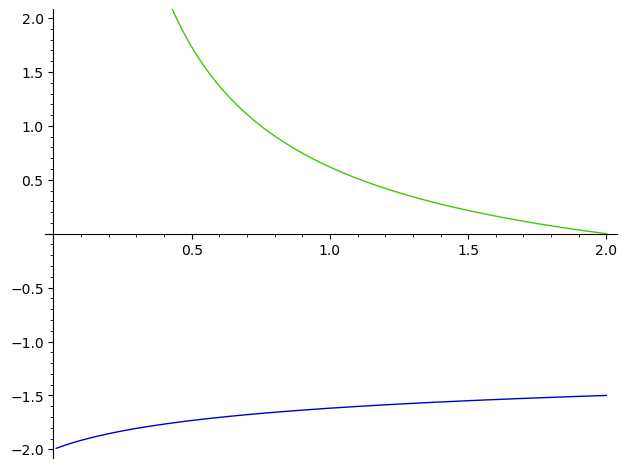

In [2]:
# Plot the two real branches of H(x,y) = 0
[y1, y2] = [Y.rhs() for Y in solve(H,y)]
plot([y1,y2],0,2,ymin=-2, ymax=2)

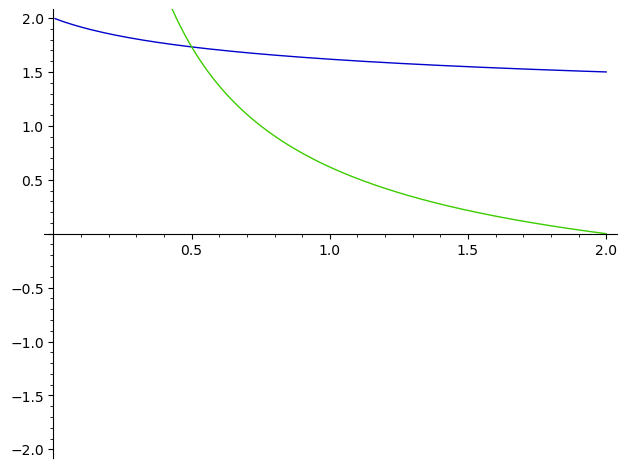

In [3]:
# These intersect after taking absolute values
plot([abs(y1),abs(y2)],0,2,ymin=-2, ymax=2)

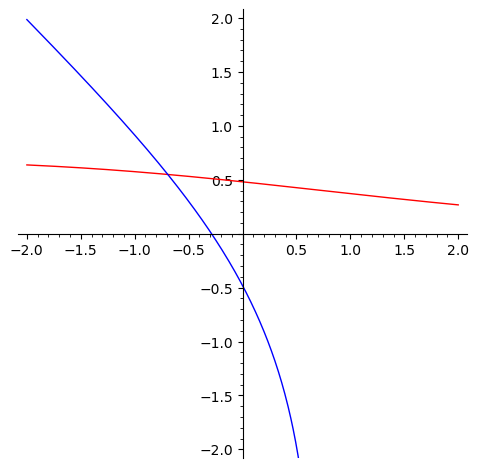

In [4]:
# They cause the cusp in the amoeba picture
p1 = parametric_plot((log(abs(x)), log(abs(y1))), (x, exp(-2), exp(2)), color='red', ymin=-2, ymax=2)
p2 = parametric_plot((log(abs(x)), log(abs(y2))), (x, exp(-2), exp(0.6)), color='blue', ymin=-2, ymax=2)
p1 + p2

### Part 2: Higher-Order Terms

In [5]:
# From here down we require the sage_acsv package to be installed
# Show higher-order terms for binomial coefficients
from sage_acsv import diagonal_asymptotics_combinatorial as diagonal
var('x y t')
show(diagonal(1/(1-x-y), expansion_precision=3))

1/sqrt(pi)*4^n*n^(-1/2) - 1/8/sqrt(pi)*4^n*n^(-3/2) + 1/128/sqrt(pi)*4^n*n^(-5/2) + O(4^n*n^(-7/2))

In [6]:
# When G vanishes at the contributing singularity the first term in 
# the asymptotic expansion also vanishes.
show(diagonal((x-2*y^2)/(1-x-y), expansion_precision=3))

1/4/sqrt(pi)*4^n*n^(-3/2) + 3/32/sqrt(pi)*4^n*n^(-5/2) + O(4^n*n^(-7/2))

In [7]:
# In this case the diagonal is identically zero but we don't detect that.
show(diagonal((x-y)/(1-x-y), expansion_precision=10))

O(4^n*n^(-21/2))

In [8]:
# Diagonal quadrant walks ending anywhere in N^2
show(diagonal((1+x)*(1+y)/(1-t*x*y*(x*y + x/y + y/x + 1/x/y))))

2/pi*4^n*n^(-1) + O(4^n*n^(-2))

In [9]:
# Diagonal quadrant walks ending on the x-axis
show(diagonal((1-x^2)*(1+y)/(1-t*x*y*(x*y + x/y + y/x + 1/x/y)), expansion_precision=2))

2/pi*4^n*n^(-2) + 2/pi*4^n*n^(-2)*(e^(I*arg(-1)))^n + O(4^n*n^(-3))

In [10]:
# Diagonal quadrant walks ending at the origin
show(diagonal((1-x^2)*(1-y^2)/(1-t*x*y*(x*y + x/y + y/x + 1/x/y)), expansion_precision=3))

4/pi*4^n*n^(-3) + 4/pi*4^n*n^(-3)*(e^(I*arg(-1)))^n + O(4^n*n^(-4))

### Part 3: Automated Asymptotics

In [11]:
# Testing out different representations for the minimal critical point system
# Use GF for horizontally convex polyominoes
var('L x y t u')
R = PolynomialRing(QQ, [x, y, t, L, u], order='lex')
H = (1 - x)^4 - x*y*(1 - x - x^2 + x^3 + x^2*y)
r = {x:2, y:1}

In [12]:
# Univariate representation. Can also try with the block elimination ordering 
# order='degrevlex(4),degrevlex(1)' -- the result is very similar
sys = [H] + [r[v]*L - v*H.derivative(v) for v in H.variables()] + [H.substitute([v==t*v for v in H.variables()])] + [u-t-x]
II = R.ideal([R(p) for p in sys]).radical()
GB = II.groebner_basis()

# Variables of each polynomial
[p.variables() for p in GB]

[(x, u), (y, u), (t, u), (L, u), (u,)]

In [13]:
# Degrees of the polynomials
[p.degrees() for p in GB]

[(1, 0, 0, 0, 10),
 (0, 1, 0, 0, 10),
 (0, 0, 1, 0, 10),
 (0, 0, 0, 1, 10),
 (0, 0, 0, 0, 11)]

In [14]:
# Max number of digits in the polynomial coefficients
[round(log(max([abs(c).numerator() for c in p.coefficients()]),10)) for p in GB]

[41, 42, 41, 42, 10]

In [15]:
# Use Kronecker representation. We remove the polynomial u - t - x from sys
# as the kronecker_representation function handles the form as an argument. 
from sage_acsv import kronecker_representation
KR = kronecker_representation(sys[0:-1], [x,y,L,t], x+t)

# Degrees of the polynomials
[p.degree() for p in KR[1]]

[10, 10, 10, 10]

In [16]:
# Max number of digits in the polynomial coefficients
[round(log(max([abs(c).numerator() for c in p.coefficients()]),10)) for p in KR[1]]

[13, 13, 16, 13]

In [17]:
# Use package to get automated asymptotics
var('x,y')
diagonal(1/(1-x-y))

1/sqrt(pi)*4^n*n^(-1/2) + O(4^n*n^(-3/2))

In [18]:
diagonal(1/(1-x-y), expansion_precision=9)

1/sqrt(pi)*4^n*n^(-1/2) - 1/8/sqrt(pi)*4^n*n^(-3/2) + 1/128/sqrt(pi)*4^n*n^(-5/2) + 5/1024/sqrt(pi)*4^n*n^(-7/2) - 21/32768/sqrt(pi)*4^n*n^(-9/2) - 399/262144/sqrt(pi)*4^n*n^(-11/2) + 869/4194304/sqrt(pi)*4^n*n^(-13/2) + 39325/33554432/sqrt(pi)*4^n*n^(-15/2) - 334477/2147483648/sqrt(pi)*4^n*n^(-17/2) + O(4^n*n^(-19/2))

In [19]:
asm = diagonal(1/(1-x-y), r=[2,1])
asm

0.866025403784439?/sqrt(pi)*(27/4)^n*n^(-1/2) + O((27/4)^n*n^(-3/2))

In [20]:
from sage_acsv import get_expansion_terms
get_expansion_terms(asm)[0].coefficient.minpoly()

x^2 - 3/4

In [21]:
# Horizontally convex polyominoes
diagonal((x*y*(1 - x)^3)/((1 - x)^4 - x*y*(1 - x - x^2 + x^3 + x^2*y)), r=[2,1])

0.2974174421957931?/sqrt(pi)*10.114572594490304?^n*n^(-1/2) + O(10.114572594490304?^n*n^(-3/2))

In [22]:
# Apéry numbers
var('w x y z')
F = 1/(1 - w*(1 + x)*(1 + y)*(1 + z)*(x*y*z + y*z + y + z + 1))
asm = diagonal(F)
asm

1.225275868941647?/pi^(3/2)*33.97056274847714?^n*n^(-3/2) + O(33.97056274847714?^n*n^(-5/2))

In [23]:
get_expansion_terms(asm)[0].base.minpoly().roots(AA, multiplicities=False)[1].radical_expression()

12*sqrt(2) + 17

### Part 4: Perturbation of Direction and Limit Theorems

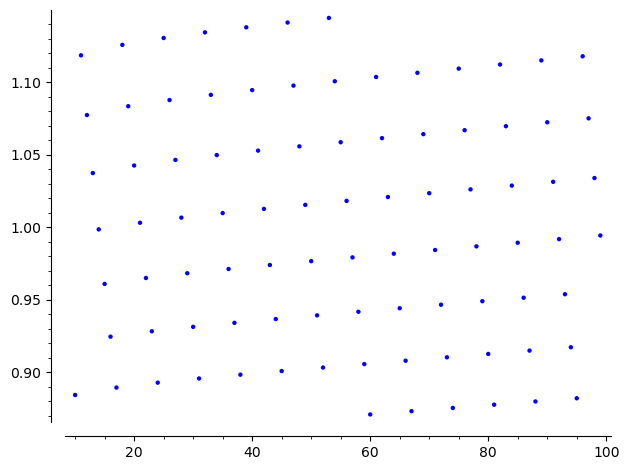

In [24]:
# Define asymptotic formula
var('r,s,n')
asm = ((r+s)/r)^(r*n) * ((r+s)/s)^(s*n) * sqrt(r+s)/sqrt(2*r*s*pi*n)

# Compute coefficients (which are just binomial coefficients)
A.<x,y> = QQ[['x,y']]
F = 1/(1-x-y+O(x^650))

# Plot ratio
point([[n,F[round(pi*n),n]/asm.subs(r=pi,s=1,n=n).n()] for n in range(10,100)])

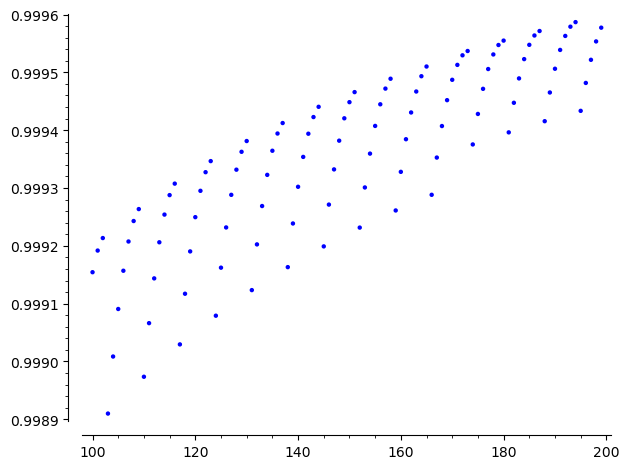

In [25]:
# Plot ratio after adding bounded correction factor
point([[n,binomial(round(pi*n)+n,n)/((pi+1)/pi)^(round(n*pi)-n*pi)/asm.subs(r=pi,s=1,n=n).n()] for n in range(100,200)])

In [26]:
# CLT for divisions in polynomial EEA over finite field
# Code to generate animation for CLT can be found on
# https://github.com/smelczer/enumeration-notebooks/blob/main/Chapter%201%20-%20Introduction.ipynb
var('u x y z z1 z2 z3 t')
from sage_acsv import central_limit_theorem_combinatorial as CLT
CLT(1/(1-3*z-6*u*z), z, as_symbolic=True)

3/2*9^n*e^(1/4*(6*n - 9*s0)*(-2/3*n + s0)/n)/(sqrt(pi)*sqrt(n))

In [27]:
# CLT for rows in horizontally convex polyominoes
# This example may be slow using Sage's Grobner basis solving. If you have the msolve package
# installed on your computer you can speed it up by running the following lines:
# from sage_acsv import ACSVSettings as AS
# AS.set_default_kronecker_backend(AS.Kronecker.MSOLVE)
F = (x*y*(1-x)^3)/((1-x)^4-x*y*(1-x-x^2+x^3+x^2*y))
CLT(F, x, as_symbolic=True)

0.3450475264519037?*3.205569430400590?^n*e^(-1/2*(-0.4530745716375183?*n + s0)*(-3.296142343669530?*n + 7.275054814390697?*s0)/n)/(sqrt(pi)*sqrt(n))

In [28]:
F = 1/(1-z1*t-z2*t^2-z3*t^3-t^4/(1-t))
CLT(F, t)

(
2, n^(-1.5), pi^(-1.5), 4.374949932957845?,

[ 348/107   16/107  112/107]                  
[  16/107 1024/107  320/107]                  
[ 112/107  320/107 2240/107], [ 1/4  1/8 1/16]
)

In [29]:
F = 1/(1-t-x*t^2-y*t^3)
CLT(F, t)

(
1.839286755214161?, n^(-1.0), pi^(-1.0), 5.030774639167280?,

[15.75001457299826? 14.61097905351492?]
[14.61097905351492? 30.36099362651318?],

[0.1828035329682955? 0.0993882723561560?]
)

### Plotting with Black Background for Slides

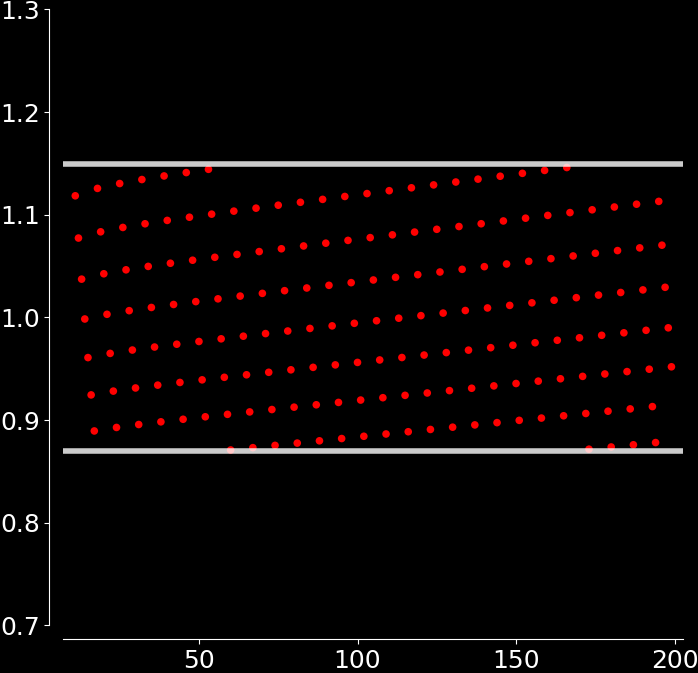

In [30]:
var('r,s,n')
asm = ((r+s)/r)^(r*n) * ((r+s)/s)^(s*n) * sqrt(r+s)/sqrt(2*r*s*pi*n)

%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.rcParams['savefig.pad_inches'] = 0
plt.rcParams['savefig.bbox'] = 'standard'
plt.style.use('dark_background')
plt.rc('font', size=14)

# Create point plot
data_points = [[n, binomial(round(pi*n)+n, n) / asm.subs(r=pi, s=1, n=n).n()] for n in range(11, 200)]
P = point(data_points, size=30, color='red', axes=False, frame=False)

# Convert to matplotlib and apply dark styling
fig = P.matplotlib(figsize=(8, 8))
fig.set_facecolor('black')
ax = fig.axes[0]

# Configure spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('white')

# Label decimal places
ax.yaxis.set_major_locator(MultipleLocator(0.1)) 
ax.tick_params(colors='white', direction='out', which='major', labelsize=18)
ax.minorticks_off()

# Horizontal lines
ax.axhline(y=((pi+1)/pi)^(0.5)+0.001, color='white', linestyle='-', linewidth=4, alpha=0.8, zorder=0)
ax.axhline(y=((pi+1)/pi)^(-0.5)-0.001, color='white', linestyle='-', linewidth=4, alpha=0.8, zorder=0)

#Viewing region
ax.set_ylim(0.7, 1.3)

# Display the plot
fig

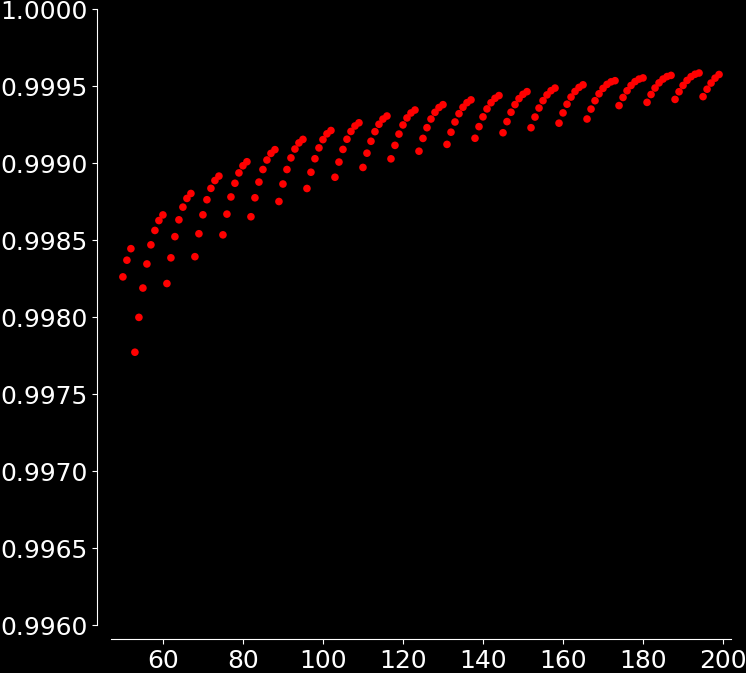

In [31]:
# Create the point plot
data_points = [[n, binomial(round(pi*n)+n, n) / ((pi+1)/pi)^(round(n*pi)-n*pi) / asm.subs(r=pi, s=1, n=n).n()] for n in range(50, 200)]
P = point(data_points, size=30, color='red', axes=False, frame=False)

# Convert to matplotlib and apply dark styling
fig = P.matplotlib(figsize=(8, 8))
fig.set_facecolor('black')
ax = fig.axes[0]

# Configure spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('white')

ax.yaxis.set_major_locator(MultipleLocator(0.0005)) 

ax.tick_params(colors='white', direction='out', which='major', labelsize=18)
ax.minorticks_off()

# Set appropriate limits for this specific dataset to frame the points nicely
ax.set_ylim(0.996, 1)

# Display the plot
fig